# Wolffia Single-Cell Atlas: Project Analysis Overview

## TL;DR

This project builds a conservative, prediction-first framework for future *Wolffia australiana* PIP-seq data. Public Arabidopsis single-cell datasets establish broad plant expression programs, test transfer across studies, compare classifiers, calibrate confidence, and define a RefSeq-based Arabidopsis-to-Wolffia ortholog feature set.

Current conclusion: the framework is technically ready for a pilot Wolffia transfer, but not for definitive cell-type annotation. Reference choice materially changes predictions, only 17% of the 2,000 Arabidopsis model features have strong reciprocal Wolffia mappings, and the ortholog-restricted model retains moderate rather than strong predictive performance. Ambiguous cells must remain ambiguous.

## 1. Biological question and workflow

**Question:** Does the morphologically simplified Wolffia plant preserve familiar flowering-plant cellular programs, merge them into compressed states, or contain poorly mapped states that are difficult to describe with Arabidopsis references?

The analysis proceeds in six stages:

1. prepare public Arabidopsis single-cell datasets
2. collapse source labels or clusters into coarse expression programs
3. train and transfer classifiers across independent Arabidopsis datasets
4. validate classifiers with entire clusters held out
5. calibrate confidence and require model/marker agreement
6. map transferable genes to Wolffia with reciprocal protein searches

The intended future outputs are program hypotheses labeled `preserved`, `weakly separable`, `compressed/merged`, or `ambiguous`.

### Key assumptions and limitations

- Broad programs are computational summaries, not established Wolffia cell types.
- GSE123818 seed labels are derived from cluster-level marker scores rather than expert-curated truth.
- UMAP supports visualization but does not prove identity or lineage.
- Reciprocal protein similarity supports putative orthology, not conserved expression or function.
- Cross-study differences can arise from tissue, treatment, chemistry, sampling, and batch effects.
- Prediction confidence is accepted only after cluster-held-out calibration and explicit rejection rules.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

KNOWN_REPO_ROOT=Path("/Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive")
def find_repo_root(start: Path) -> Path:
    for candidate in [start,*start.parents]:
        if (candidate/'README.md').exists() and (candidate/'results').exists():
            return candidate
    if KNOWN_REPO_ROOT.exists():
        return KNOWN_REPO_ROOT
    raise FileNotFoundError('Project root not found')

REPO_ROOT=find_repo_root(Path.cwd().resolve())
print('Repository:',REPO_ROOT)

def load_json(path: Path):
    with open(path) as handle:
        return json.load(handle)

def show_image(path: Path,width=1000):
    if path.exists():
        display(Image(filename=str(path),width=width))
    else:
        display(Markdown(f'> Figure not found locally: `{path.relative_to(REPO_ROOT)}`'))

Repository: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive


## 2. Public reference datasets

The project intentionally uses datasets with different biological contexts. This reveals whether a program is robust across experiments or merely reflects one reference.

In [2]:
dataset_manifest=pd.read_csv(REPO_ROOT/'data'/'metadata'/'arabidopsis_public_dataset_manifest.csv')
display(dataset_manifest[[
 'dataset_id','geo_accession','title','organism','assay','role','priority',
 'current_status','expected_strength','likely_label_status'
]].style.hide(axis='index'))

dataset_id,geo_accession,title,organism,assay,role,priority,current_status,expected_strength,likely_label_status
GSE121619_root_control_heatshock,GSE121619,Dynamics_of_gene_expression_in_single_root_cells_of_A_thaliana,Arabidopsis thaliana,scRNA-seq,broad_validation_candidate,high,converted_to_local_h5ad,strong_for_trajectory_and_condition_response,cluster_level_not_curated_cell_types
GSE123818_root_atlas,GSE123818,Spatiotemporal_Developmental_Trajectories_in_the_Arabidopsis_Root_Revealed_Using_High_Throughput_Single_Cell_RNA_Sequencing,Arabidopsis thaliana,scRNA-seq,broad_reference_candidate,high,converted_to_local_h5ad,strong_for_root_developmental_atlas,broad_root_states_present_but_cell_annotations_may_require_reconstruction
GSE181999_phloem_pole_atlas,GSE181999,An_Arabidopsis_root_phloem_pole_cell_atlas_reveals_PINEAPPLE_genes_as_transitioners_to_autotrophy,Arabidopsis thaliana,10x_scRNA-seq,targeted_validation_candidate,high,metadata_verified,strong_for_vascular_transport_program_validation,reporter_sorted_subpopulations_more_informative_than_global_cell_types
GSE308672_root_hypoxia_snRNA,GSE308672,Discrete_and_cell_specific_hypoxic_responses_in_Arabidopsis_roots_resolved_by_single_nuclei_transcriptomics,Arabidopsis thaliana,snRNA-seq,stress_validation_candidate,medium,metadata_verified,strong_for_stress_program_specificity,annotation_status_unknown


## 3. Cross-dataset Arabidopsis transfer

Early callus-trained transfers frequently collapsed most target cells into one stress-like category. Root-trained analyses were more balanced, demonstrating that reference choice materially affects the result.

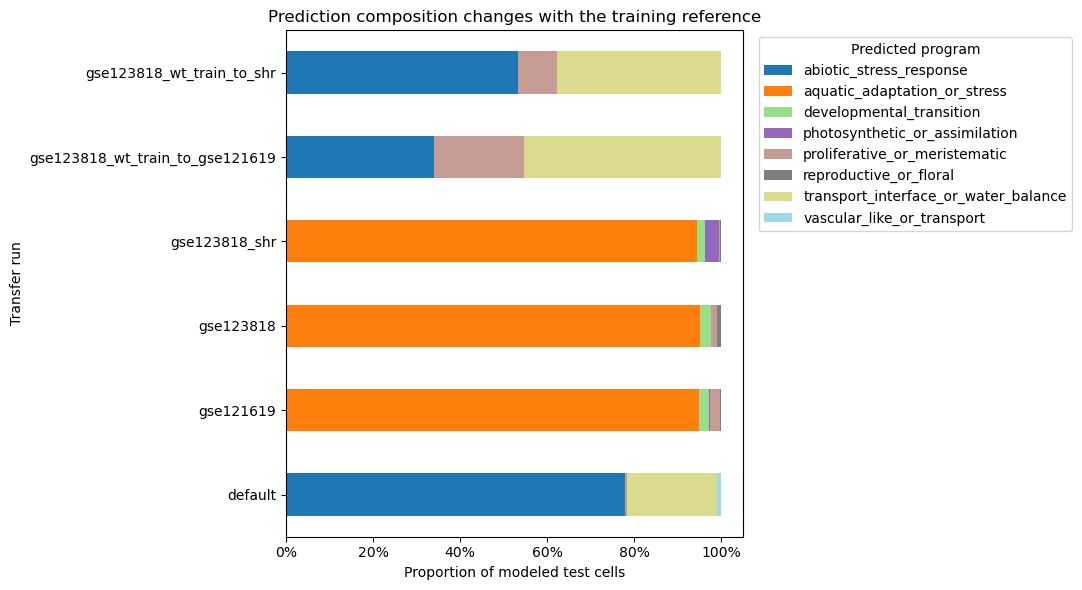

run,train,test,program,proportion
default,GSE227564_callus,GSE141730_root_phosphate,abiotic_stress_response,77.8%
gse121619,GSE227564_callus,GSE121619_all_root,aquatic_adaptation_or_stress,95.0%
gse123818,GSE227564_callus,GSE123818_wt_root,aquatic_adaptation_or_stress,95.2%
gse123818_shr,GSE227564_callus,GSE123818_shr_root,aquatic_adaptation_or_stress,94.4%
gse123818_wt_train_to_gse121619,GSE123818_wt_root,GSE121619_all_root,transport_interface_or_water_balance,45.4%
gse123818_wt_train_to_shr,GSE123818_wt_root,GSE123818_shr_root,abiotic_stress_response,53.2%


In [3]:
comparison_rows=[]
for result_dir in sorted((REPO_ROOT/'results').glob('public_reference*')):
    metrics_path=result_dir/'cross_dataset_metrics.json'
    counts_path=result_dir/'predicted_label_counts.csv'
    if not metrics_path.exists() or not counts_path.exists():
        continue
    metrics=load_json(metrics_path)
    counts=pd.read_csv(counts_path)
    total=counts.n_cells.sum()
    for row in counts.itertuples(index=False):
        comparison_rows.append({
            'run':result_dir.name.removeprefix('public_reference').lstrip('_') or 'default',
            'train':metrics['train_dataset_name'],
            'test':metrics['test_dataset_name'],
            'program':row.predicted_broad_program,
            'proportion':row.n_cells/total,
        })
cross_run=pd.DataFrame(comparison_rows)
pivot=cross_run.pivot_table(index='run',columns='program',values='proportion',fill_value=0)
pivot.plot(kind='barh',stacked=True,figsize=(11,6),colormap='tab20')
plt.xlabel('Proportion of modeled test cells'); plt.ylabel('Transfer run')
plt.title('Prediction composition changes with the training reference')
plt.gca().xaxis.set_major_formatter(lambda x,pos:f'{x:.0%}')
plt.legend(title='Predicted program',bbox_to_anchor=(1.02,1),loc='upper left')
plt.tight_layout(); plt.show()

dominance=(cross_run.sort_values(['run','proportion'],ascending=[True,False]).groupby('run',as_index=False).first())
display(dominance[['run','train','test','program','proportion']].style.format({'proportion':'{:.1%}'}).hide(axis='index'))

In [4]:
callus=dominance[dominance['train'].str.contains('GSE227564',na=False)]['proportion'].median()
root=dominance[~dominance['train'].str.contains('GSE227564',na=False)]['proportion'].median()
display(Markdown(f"""
### Interpretation

The median dominant-program share is **{callus:.1%}** for callus-trained runs and **{root:.1%}** for root-trained runs. The reduction after switching references is evidence that the earlier stress collapse was partly reference-dependent. It should not be interpreted as proof that stress biology is absent or present in Wolffia.
"""))


### Interpretation

The median dominant-program share is **94.7%** for callus-trained runs and **49.3%** for root-trained runs. The reduction after switching references is evidence that the earlier stress collapse was partly reference-dependent. It should not be interpreted as proof that stress biology is absent or present in Wolffia.


### Root-trained UMAP examples

These UMAPs visualize predictions from the GSE123818 wild-type root reference in two independent root targets. Local coherence is encouraging, but these targets lack matching broad-program ground truth.

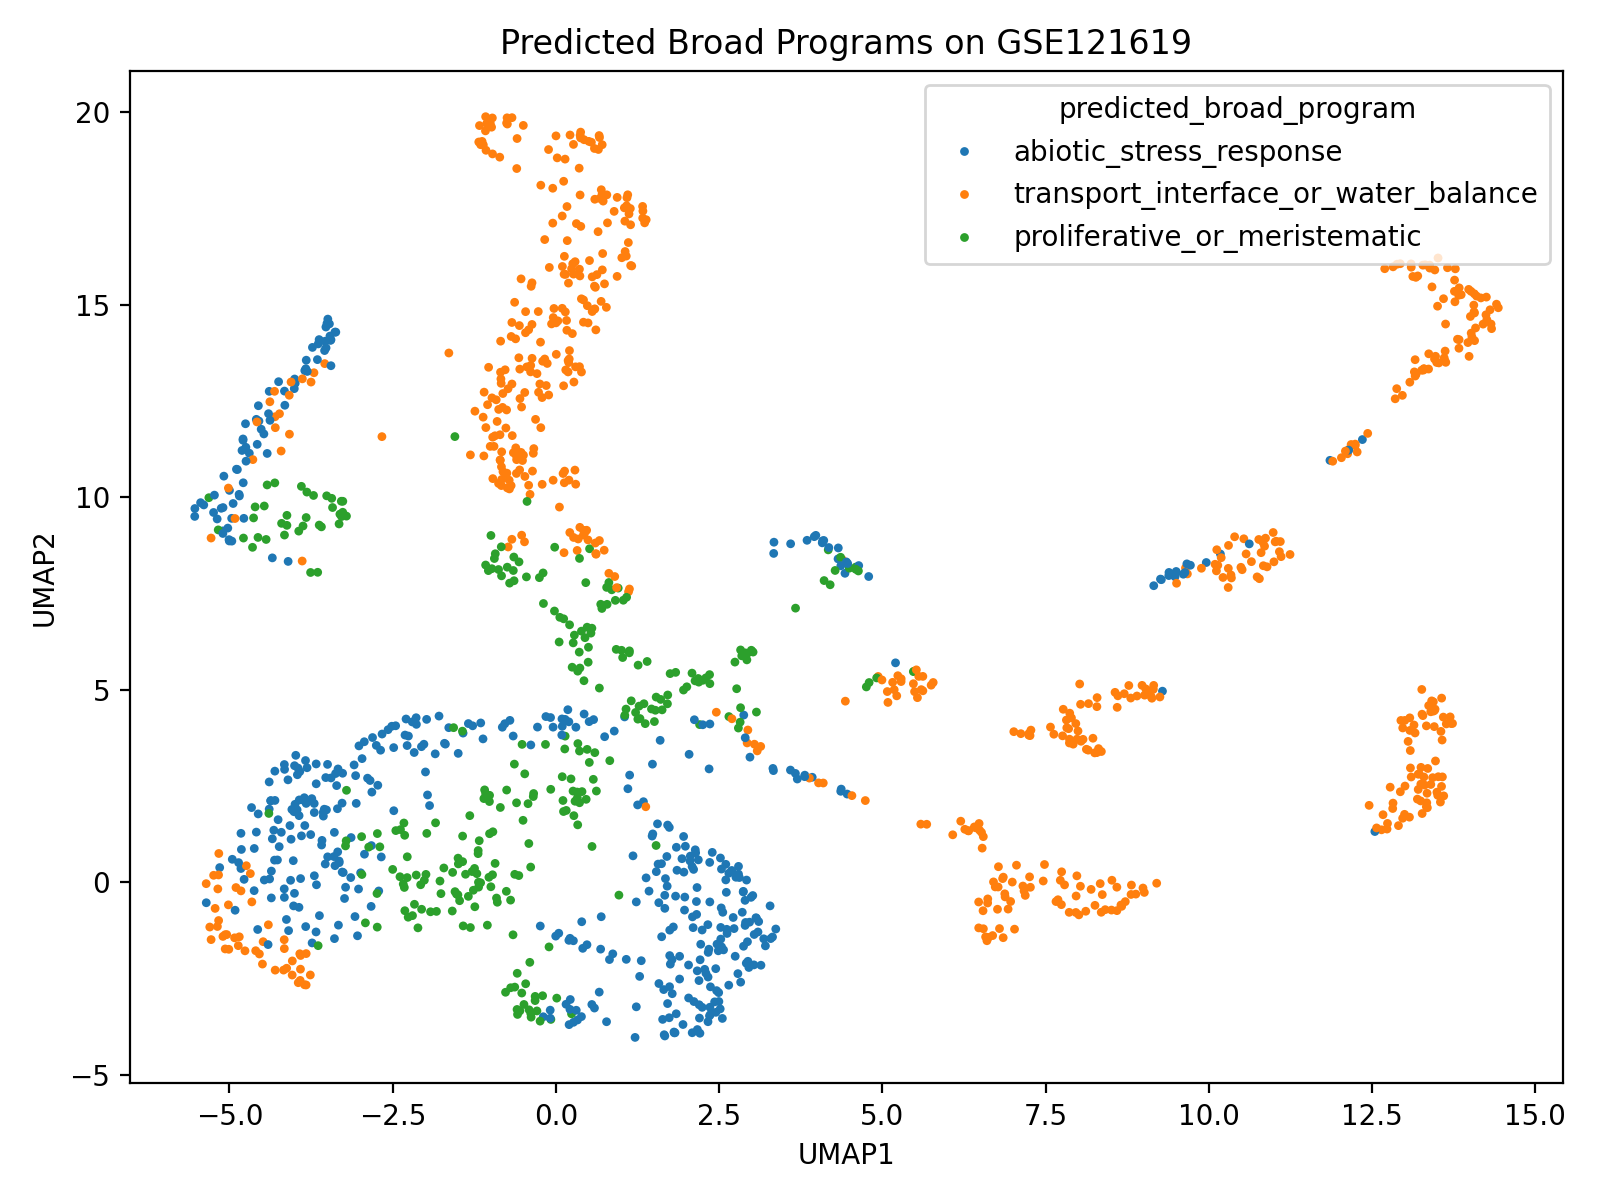

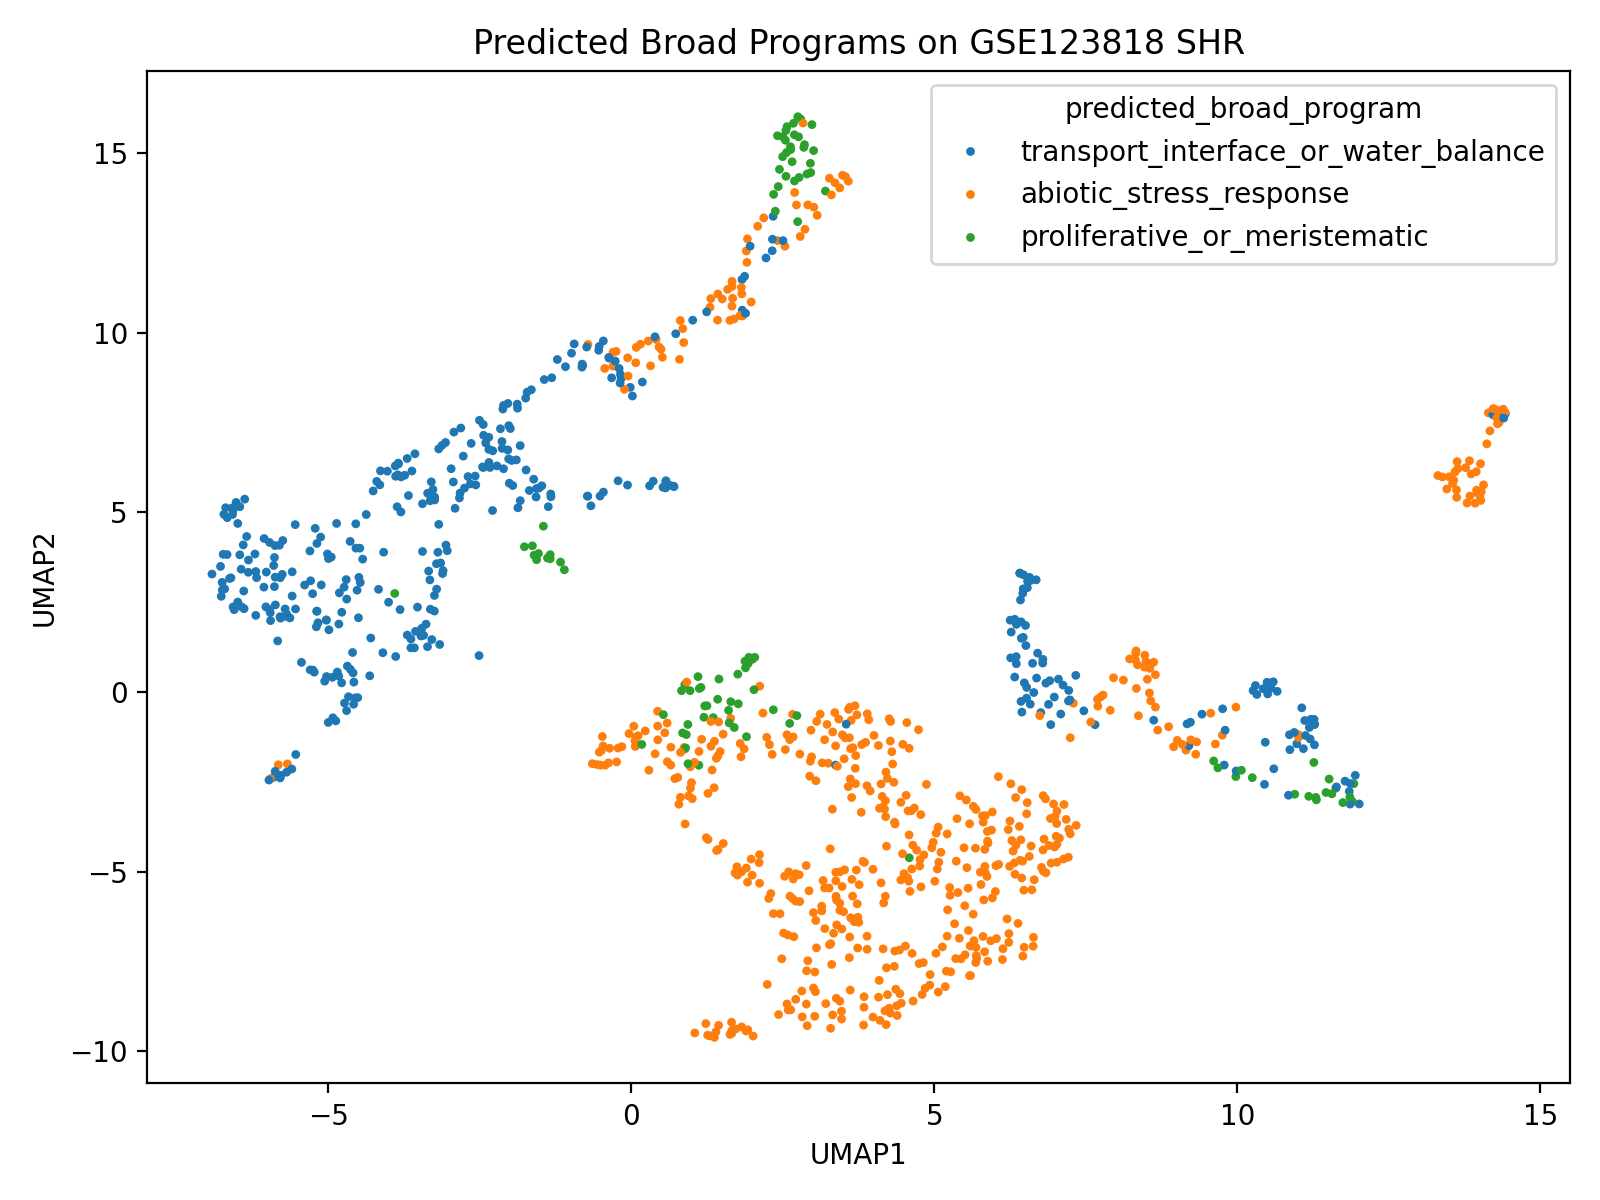

In [5]:
show_image(REPO_ROOT/'figures'/'public_reference_gse123818_wt_train_to_gse121619'/'test_predicted_broad_program_umap.png',900)
show_image(REPO_ROOT/'figures'/'public_reference_gse123818_wt_train_to_shr'/'test_predicted_broad_program_umap.png',900)

## 4. Cluster-held-out classifier validation

Random cell splitting would place closely related cells from the same cluster in training and test data. The benchmark instead holds out entire GSE123818 Leiden clusters. Two folds are used because the proliferative program contains only two independent seed clusters.

model,accuracy,balanced_accuracy,macro_f1,log_loss,mean_confidence,expected_calibration_error,temperature,calibrated_log_loss,calibrated_mean_confidence,calibrated_expected_calibration_error
logistic_regression,0.720,0.650,0.637,2.061,0.955,0.233,6.171,0.706,0.707,0.055
random_forest,0.698,0.588,0.586,0.781,0.752,0.062,1.374,0.742,0.683,0.028


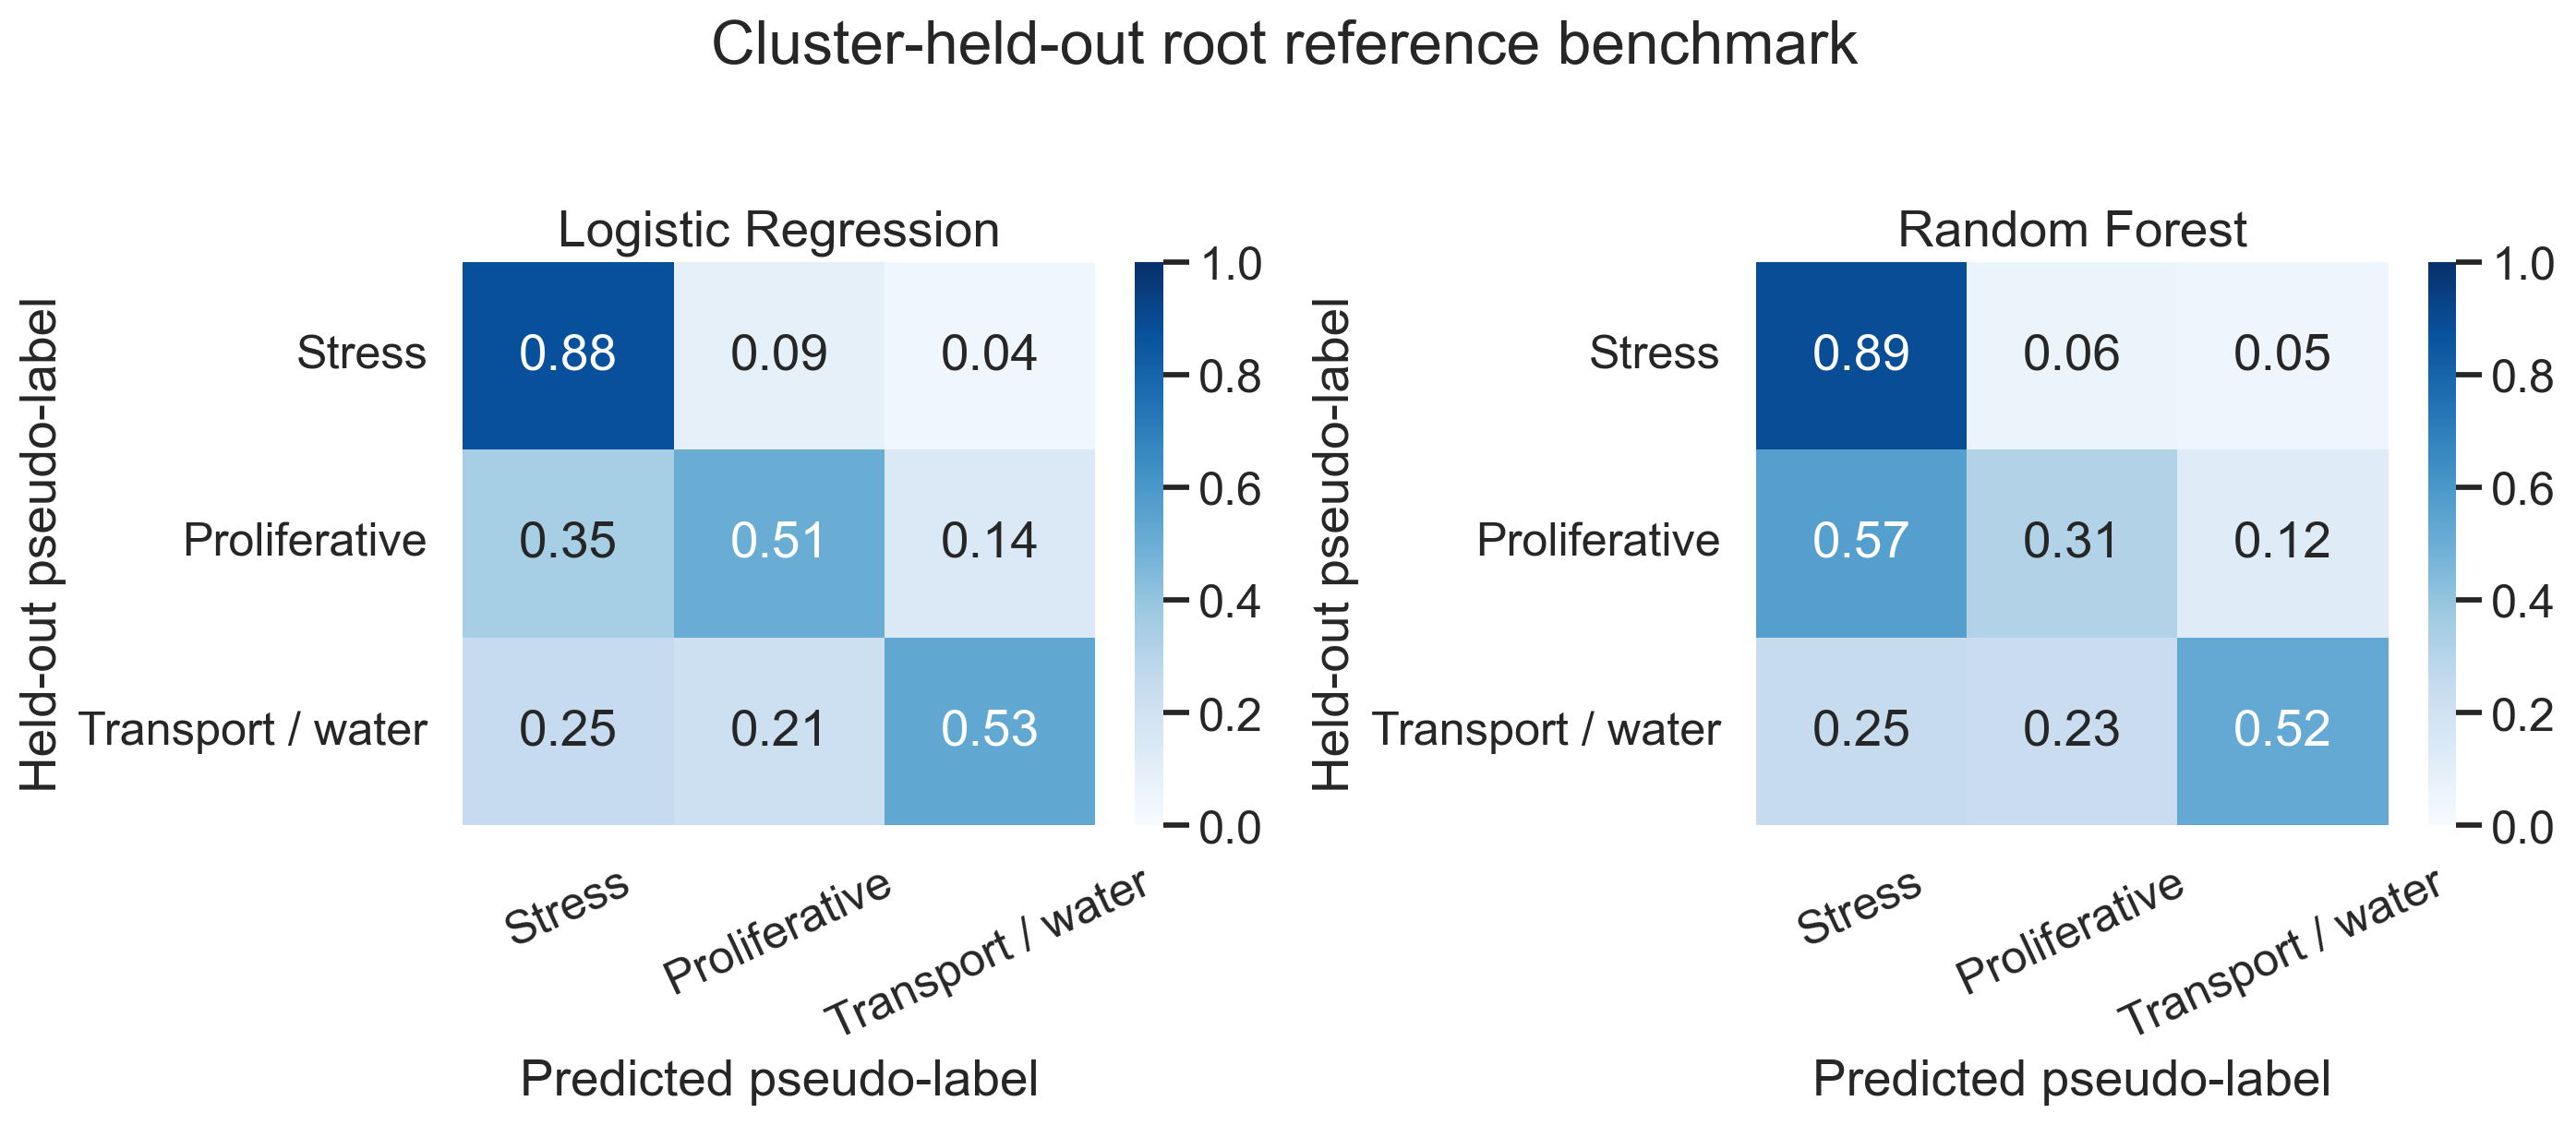

In [6]:
ROOT_RESULT=REPO_ROOT/'results'/'root_reference_consensus'
root_metrics=pd.read_csv(ROOT_RESULT/'model_comparison_summary.csv')
root_summary=load_json(ROOT_RESULT/'benchmark_summary.json')
display(root_metrics.style.format({
 'accuracy':'{:.3f}','balanced_accuracy':'{:.3f}','macro_f1':'{:.3f}',
 'log_loss':'{:.3f}','mean_confidence':'{:.3f}',
 'expected_calibration_error':'{:.3f}','temperature':'{:.3f}',
 'calibrated_log_loss':'{:.3f}','calibrated_mean_confidence':'{:.3f}',
 'calibrated_expected_calibration_error':'{:.3f}',
}).hide(axis='index'))
show_image(REPO_ROOT/'figures'/'root_reference_consensus'/'cluster_heldout_confusion_matrices.png',1200)

### Interpretation

Stress pseudo-labels are recovered most reliably. Proliferative and transport/water programs are only moderately separable and often collapse toward stress. Logistic regression has better balanced accuracy, while random forest contributes better raw uncertainty behavior. The two models are therefore used as an agreement filter rather than competing for a single winner.

## 5. Confidence calibration and conservative consensus

Temperature scaling is fitted from cluster-held-out predictions. It preserves each model's label ranking while correcting the certainty claimed by its probabilities.

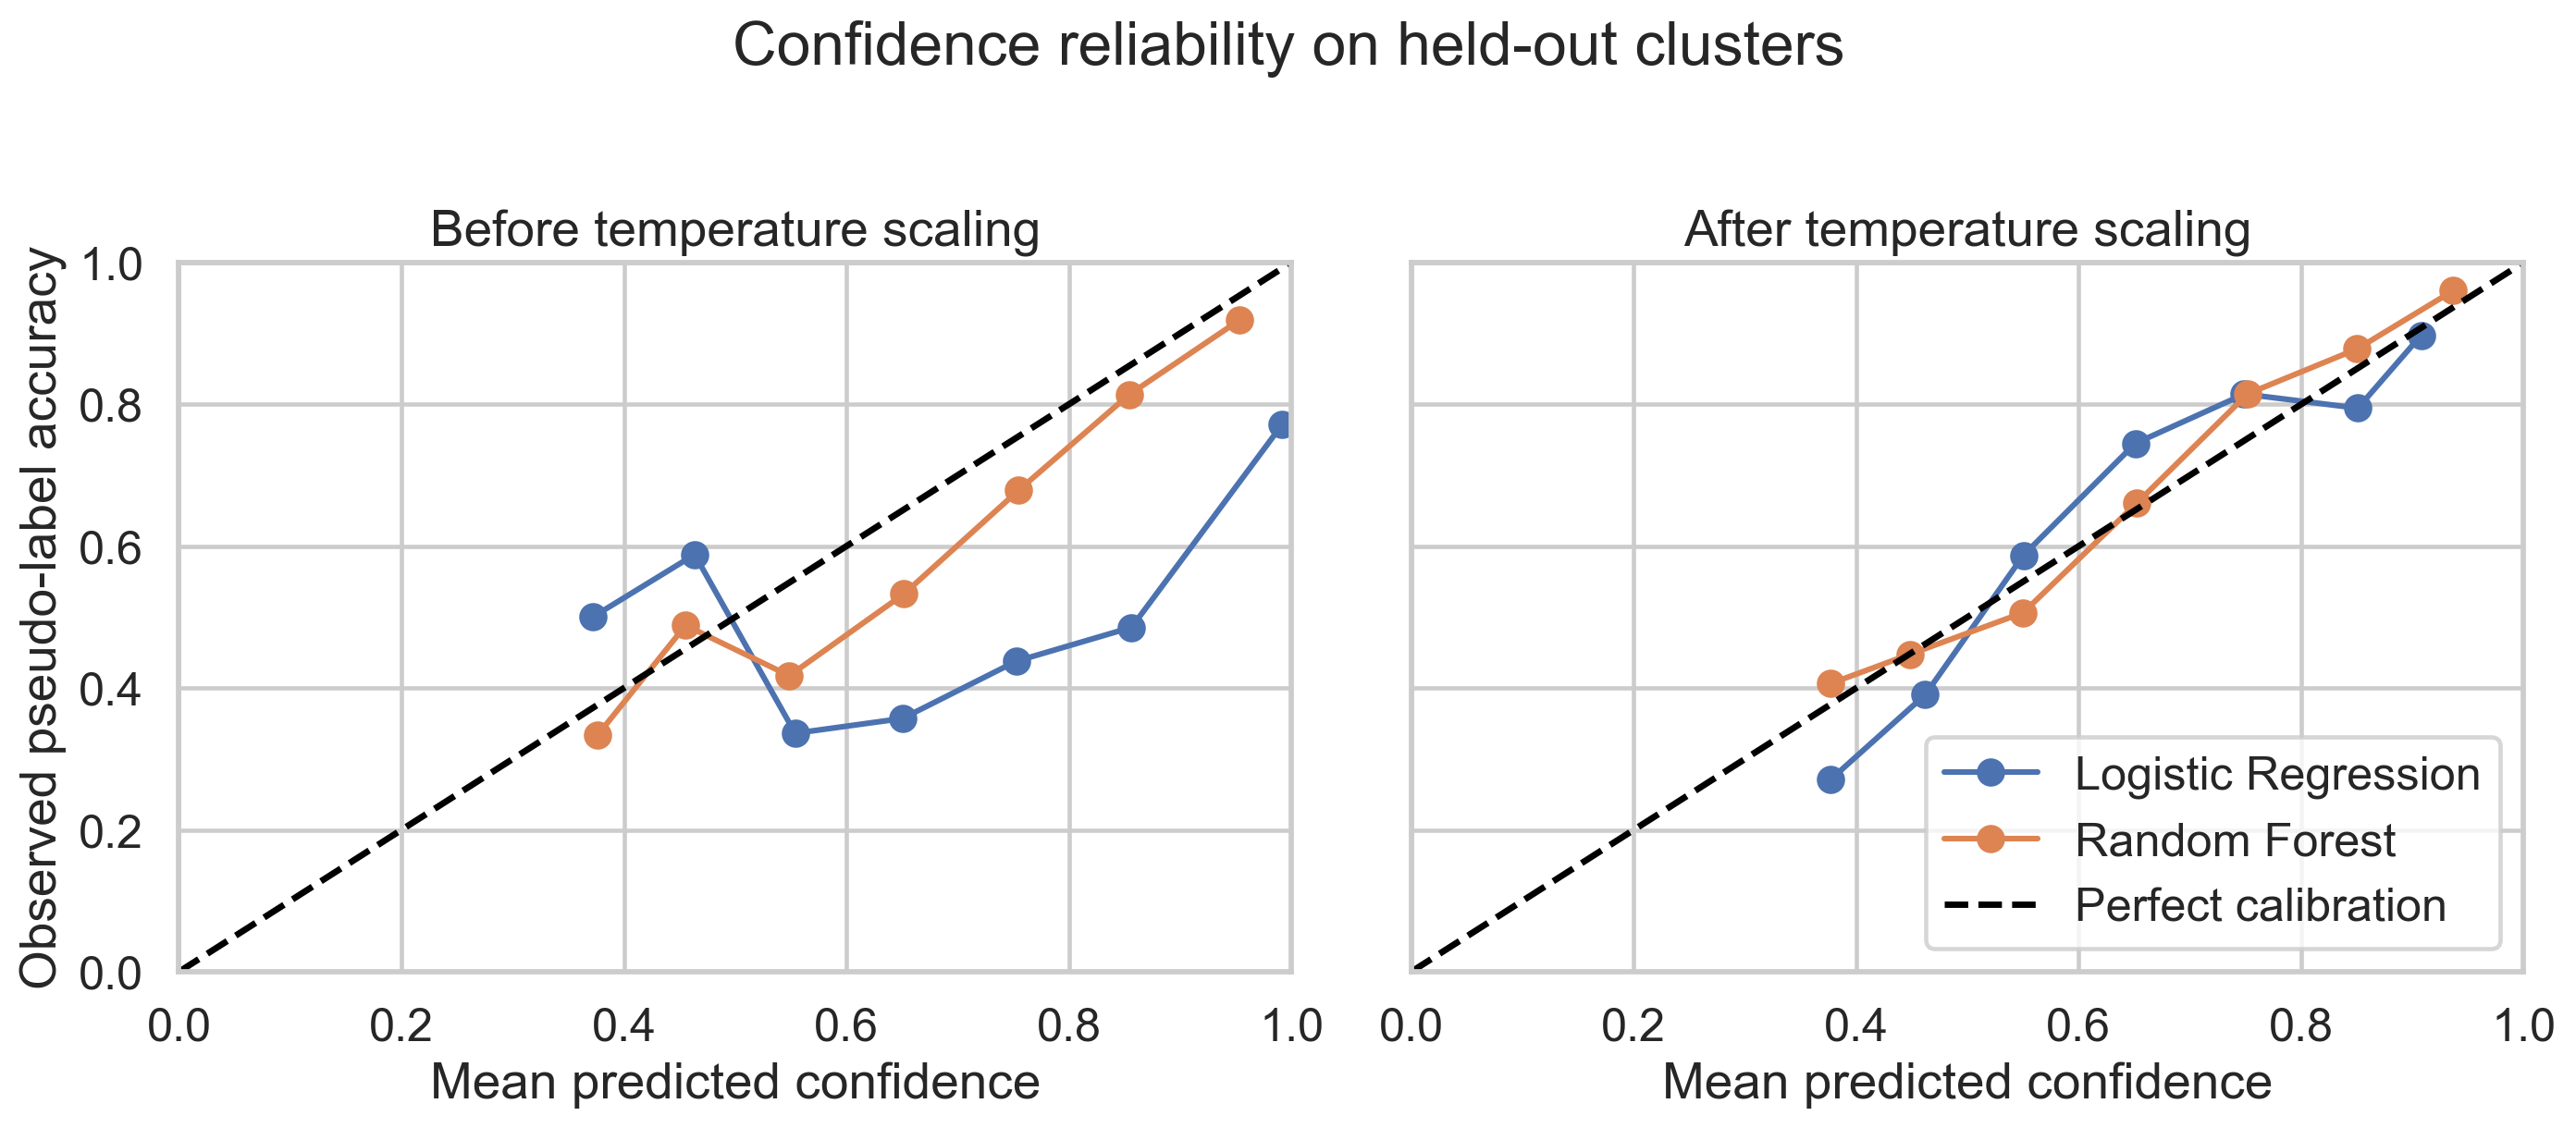

label,n_cells,proportion
ambiguous,1265,60.7%
transport_interface_or_water_balance,705,33.8%
proliferative_or_meristematic,60,2.9%
abiotic_stress_response,55,2.6%


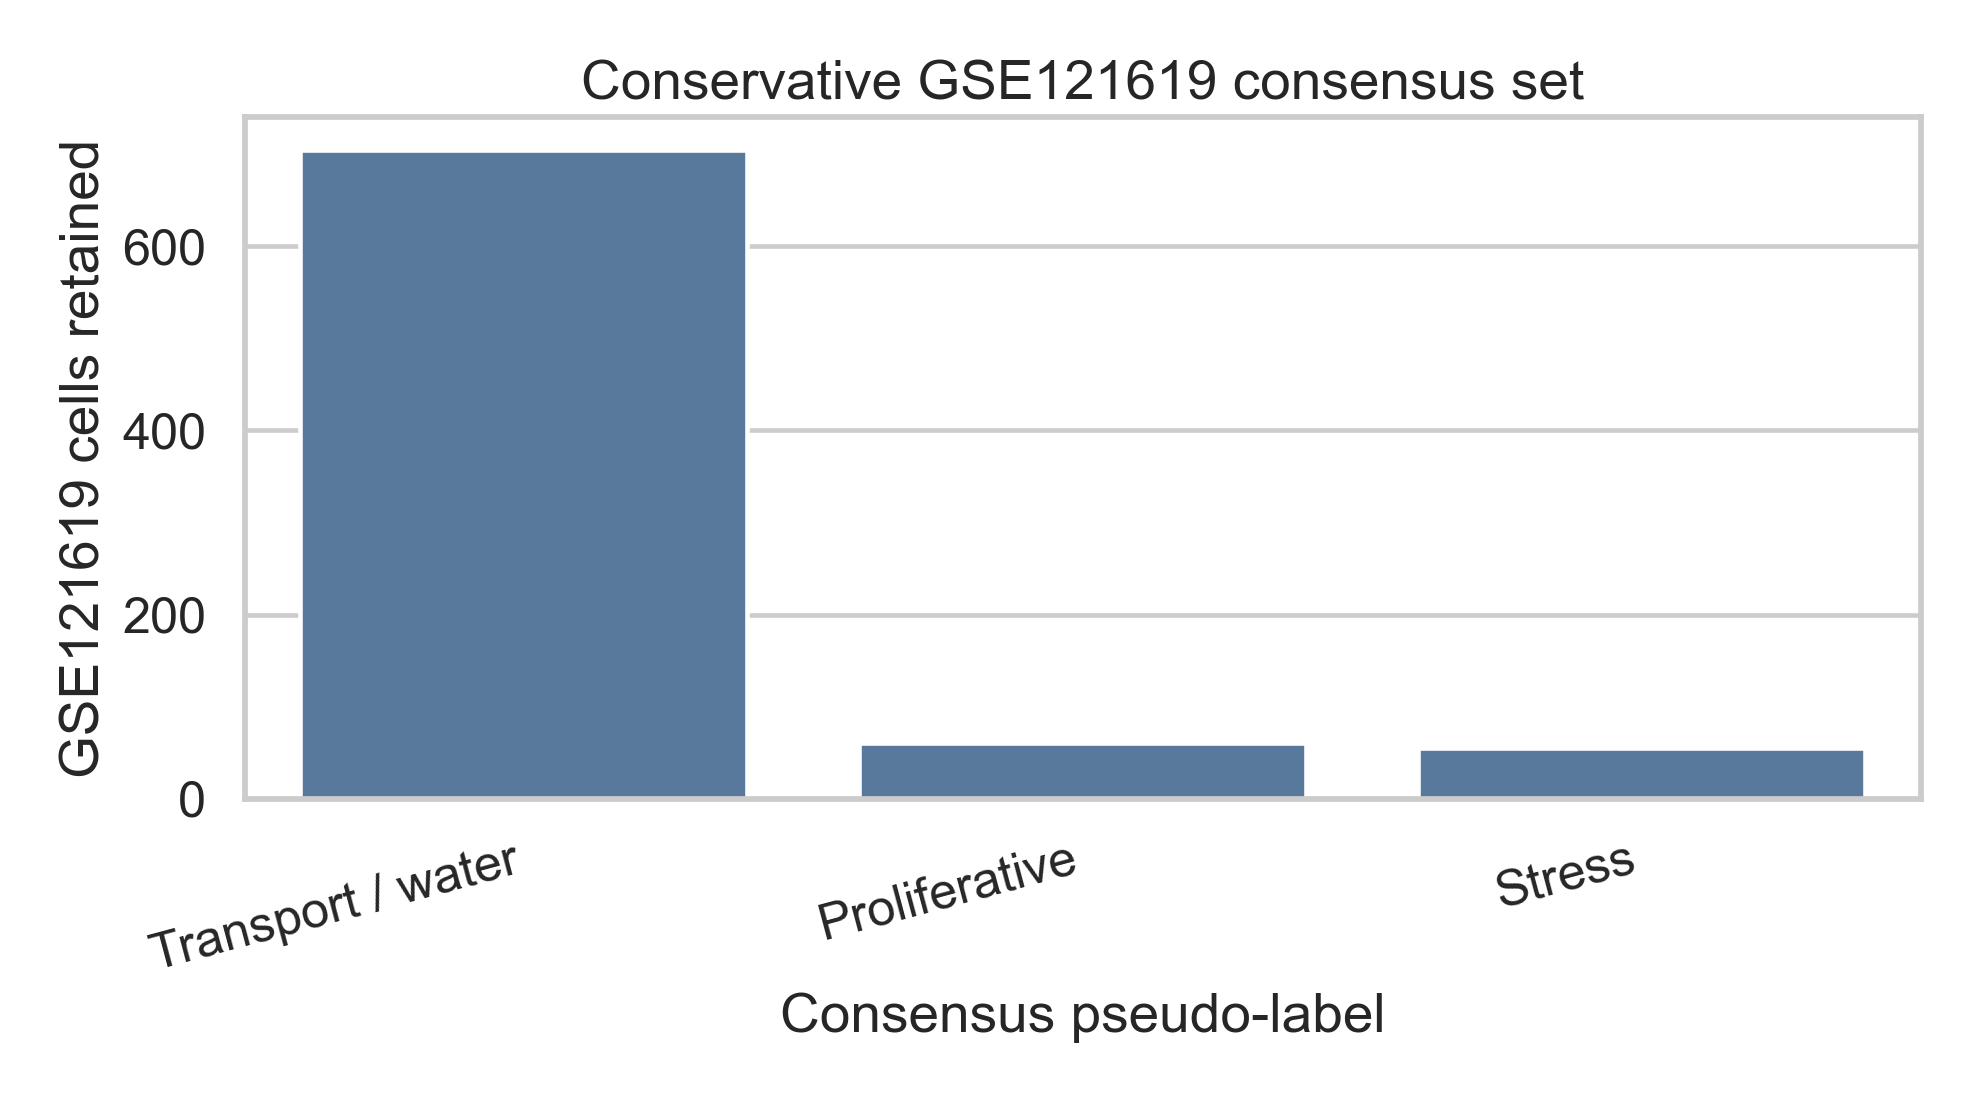

In [7]:
show_image(REPO_ROOT/'figures'/'root_reference_consensus'/'classifier_confidence_reliability.png',1000)
consensus=pd.read_csv(ROOT_RESULT/'gse121619_consensus_predictions.csv')
consensus_counts=consensus.consensus_label.value_counts().rename_axis('label').reset_index(name='n_cells')
consensus_counts['proportion']=consensus_counts.n_cells/len(consensus)
display(consensus_counts.style.format({'proportion':'{:.1%}'}).hide(axis='index'))
show_image(REPO_ROOT/'figures'/'root_reference_consensus'/'gse121619_consensus_counts.png',900)

In [8]:
logistic=root_metrics.set_index('model').loc['logistic_regression']
forest=root_metrics.set_index('model').loc['random_forest']
display(Markdown(f"""
### Interpretation

Temperature scaling lowers calibration error from **{logistic.expected_calibration_error:.3f} to {logistic.calibrated_expected_calibration_error:.3f}** for logistic regression and from **{forest.expected_calibration_error:.3f} to {forest.calibrated_expected_calibration_error:.3f}** for random forest. After calibration and marker/model agreement filtering, **{root_summary['n_consensus_accepted']:,} of {root_summary['n_second_root_cells']:,} cells ({root_summary['consensus_acceptance_rate']:.1%})** are retained. The remaining **{1-root_summary['consensus_acceptance_rate']:.1%}** are explicitly ambiguous.
"""))


### Interpretation

Temperature scaling lowers calibration error from **0.233 to 0.055** for logistic regression and from **0.062 to 0.028** for random forest. After calibration and marker/model agreement filtering, **820 of 2,085 cells (39.3%)** are retained. The remaining **60.7%** are explicitly ambiguous.


## 6. Arabidopsis-to-Wolffia ortholog mapping

The mapping uses NCBI RefSeq Arabidopsis `GCF_000001735.4` and Wolffia `GCF_029677425.1`. Longest protein isoforms are compared in both directions with DIAMOND. High/medium mappings require reciprocal best-hit support; directional family hits remain low confidence.

confidence,n_features,proportion
high,217,10.8%
medium,123,6.2%
low,874,43.7%
unmapped,786,39.3%


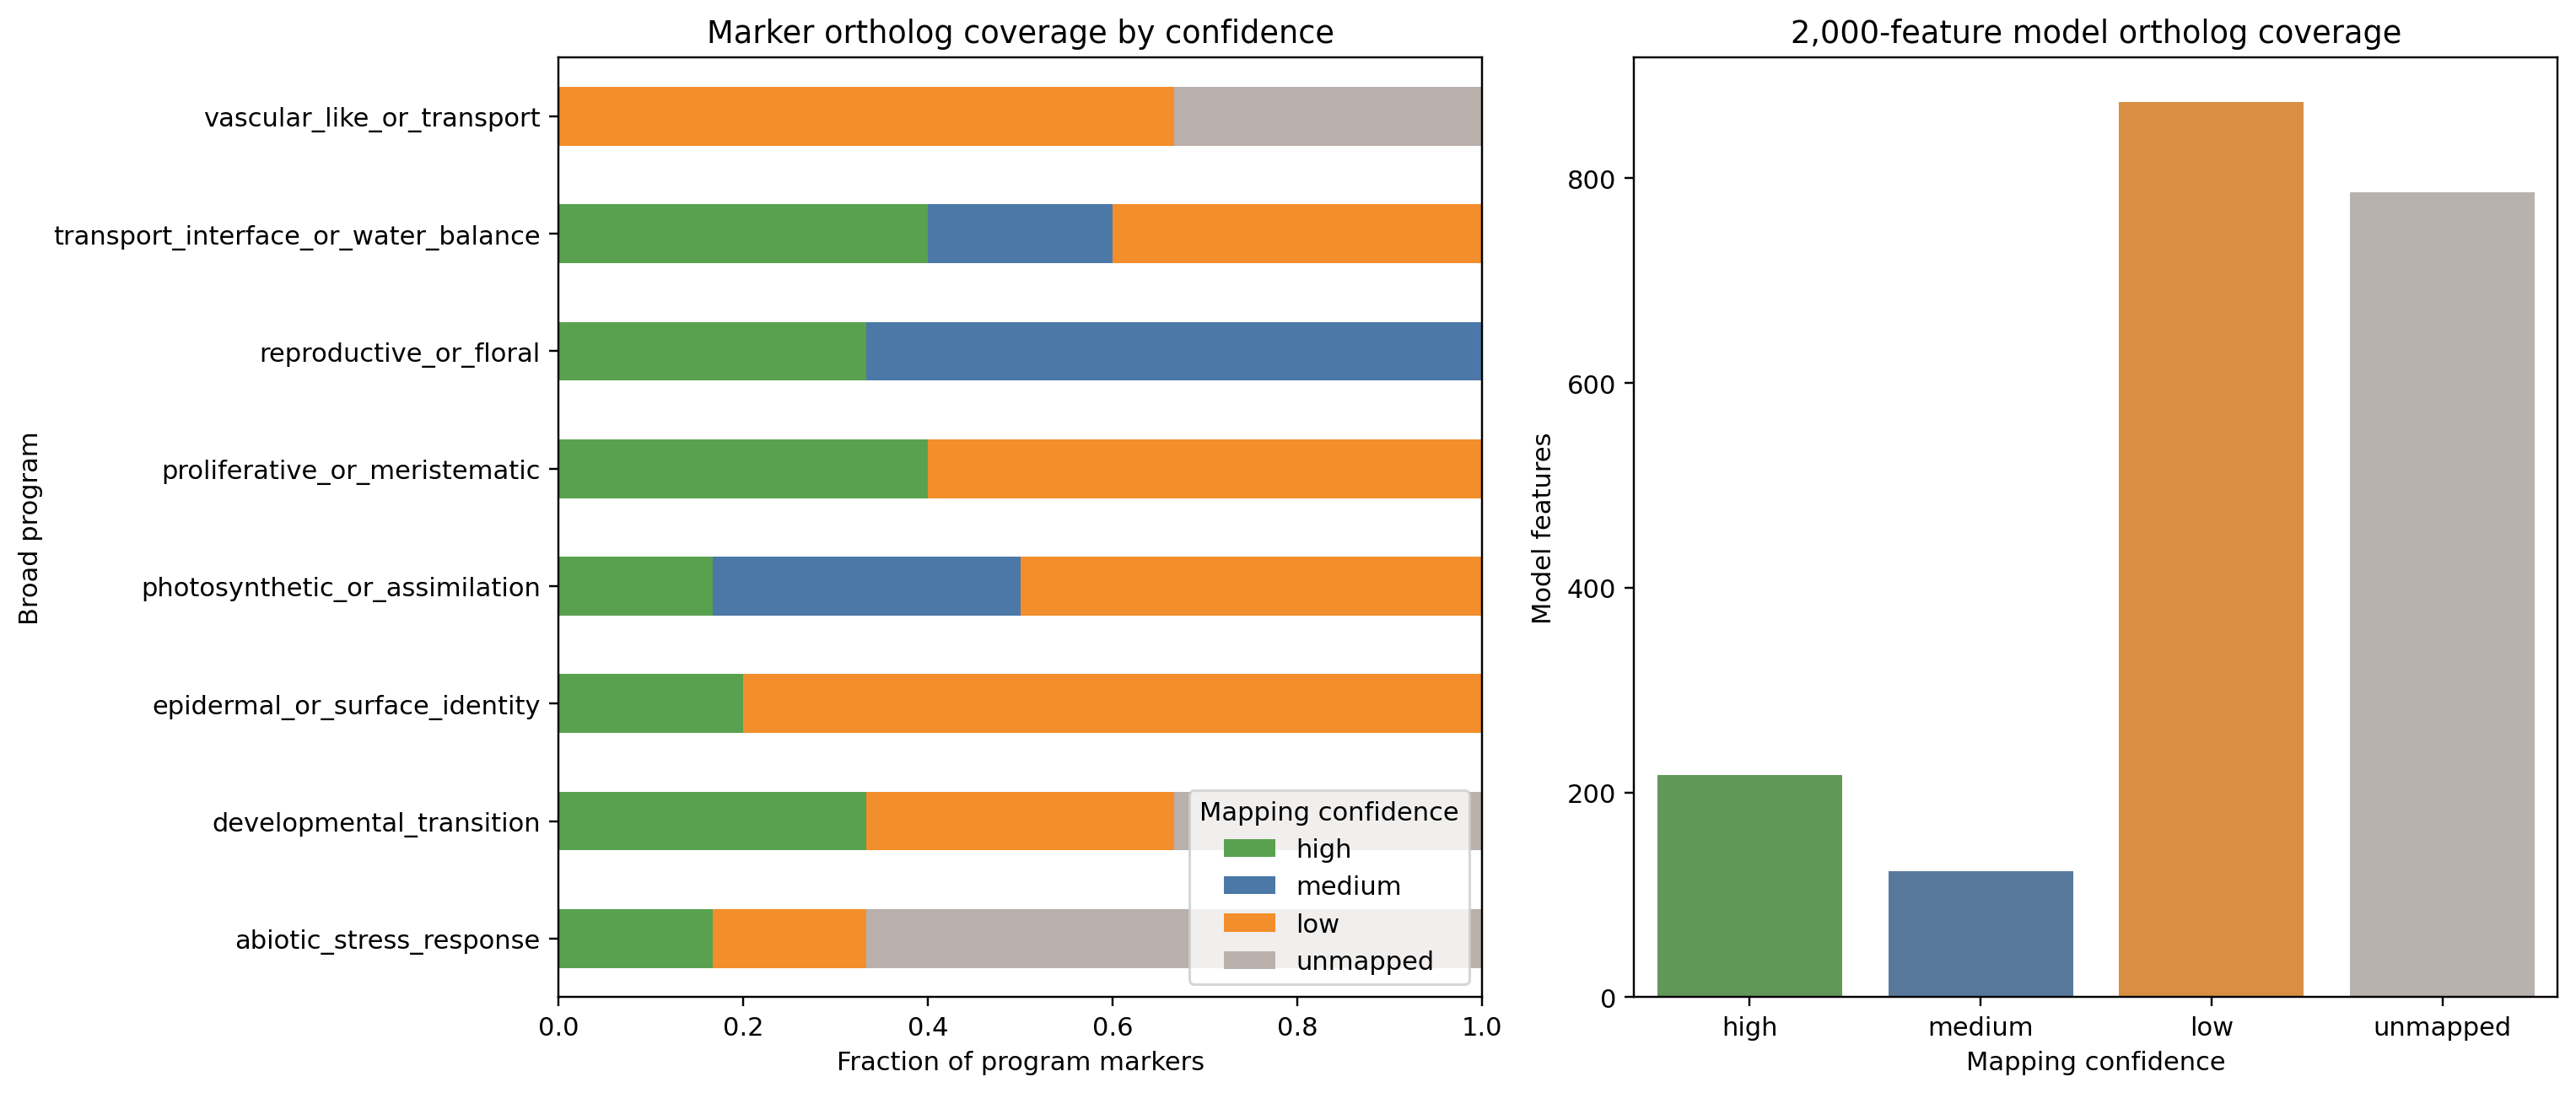

In [9]:
ORTHO_RESULT=REPO_ROOT/'results'/'orthology'
orthology_summary=load_json(ORTHO_RESULT/'orthology_summary.json')
model_mapping=pd.read_csv(REPO_ROOT/'data'/'metadata'/'arabidopsis_wolffia_model_orthologs.csv')
marker_mapping=pd.read_csv(REPO_ROOT/'data'/'metadata'/'wolffia_program_marker_orthologs.csv')
coverage=pd.read_csv(ORTHO_RESULT/'program_ortholog_coverage.csv')
confidence=model_mapping.mapping_confidence.value_counts().reindex(['high','medium','low','unmapped'],fill_value=0)
confidence_table=confidence.rename_axis('confidence').reset_index(name='n_features')
confidence_table['proportion']=confidence_table.n_features/len(model_mapping)
display(confidence_table.style.format({'proportion':'{:.1%}'}).hide(axis='index'))
show_image(REPO_ROOT/'figures'/'orthology'/'ortholog_coverage_summary.png',1200)

### Interpretation

Only 340 of 2,000 model features (17.0%) meet strict high/medium reciprocal criteria. Low-confidence hits often represent plausible gene-family relationships, but they cannot safely be treated as one-to-one features. Marker coverage is especially weak for stress and vascular panels, so apparent absence of those programs would be uninterpretable without marker refinement.

## 7. Ortholog-restricted model test

A model cannot be transferred by simply renaming all Arabidopsis genes. The root benchmark was retrained using only the 340 high/medium-confidence mapped genes.

feature_scope,model,balanced_accuracy,macro_f1,calibrated_expected_calibration_error
"2,000-gene Arabidopsis benchmark",logistic_regression,0.650,0.637,0.055
"2,000-gene Arabidopsis benchmark",random_forest,0.588,0.586,0.028
340-gene ortholog restricted,logistic_regression,0.528,0.535,0.078
340-gene ortholog restricted,random_forest,0.474,0.463,0.099


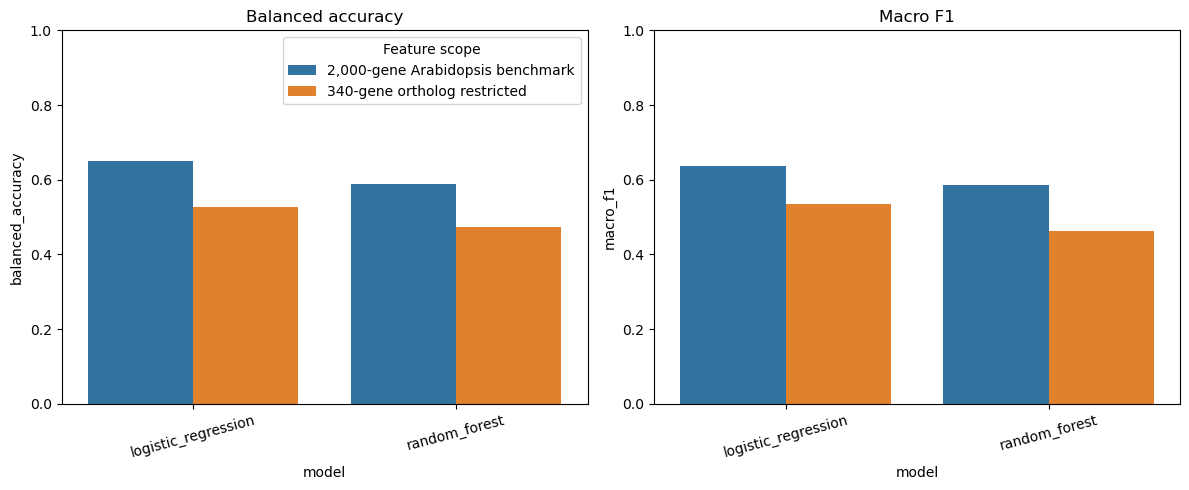

In [10]:
RESTRICTED_RESULT=REPO_ROOT/'results'/'root_reference_consensus_ortholog_restricted'
restricted_metrics=pd.read_csv(RESTRICTED_RESULT/'model_comparison_summary.csv')
restricted_summary=load_json(RESTRICTED_RESULT/'benchmark_summary.json')
comparison=pd.concat([
 root_metrics.assign(feature_scope='2,000-gene Arabidopsis benchmark'),
 restricted_metrics.assign(feature_scope='340-gene ortholog restricted'),
],ignore_index=True)
display(comparison[['feature_scope','model','balanced_accuracy','macro_f1','calibrated_expected_calibration_error']].style.format({
 'balanced_accuracy':'{:.3f}','macro_f1':'{:.3f}','calibrated_expected_calibration_error':'{:.3f}'
}).hide(axis='index'))
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.barplot(data=comparison,x='model',y='balanced_accuracy',hue='feature_scope',ax=axes[0])
sns.barplot(data=comparison,x='model',y='macro_f1',hue='feature_scope',ax=axes[1])
for axis,title in zip(axes,['Balanced accuracy','Macro F1']):
    axis.set_ylim(0,1); axis.set_title(title); axis.tick_params(axis='x',rotation=15)
axes[1].get_legend().remove(); axes[0].legend(title='Feature scope')
fig.tight_layout(); plt.show()

In [11]:
full=root_metrics.set_index('model')
restricted=restricted_metrics.set_index('model')
display(Markdown(f"""
### Interpretation

Ortholog restriction lowers logistic balanced accuracy by **{full.loc['logistic_regression','balanced_accuracy']-restricted.loc['logistic_regression','balanced_accuracy']:.3f}** and random-forest balanced accuracy by **{full.loc['random_forest','balanced_accuracy']-restricted.loc['random_forest','balanced_accuracy']:.3f}**. Only **{restricted_summary['n_consensus_accepted']:,} of {restricted_summary['n_second_root_cells']:,} cells ({restricted_summary['consensus_acceptance_rate']:.1%})** pass the restricted consensus. Transferable genes retain signal, but not enough for fine-grained or forced annotation.
"""))


### Interpretation

Ortholog restriction lowers logistic balanced accuracy by **0.123** and random-forest balanced accuracy by **0.114**. Only **552 of 2,085 cells (26.5%)** pass the restricted consensus. Transferable genes retain signal, but not enough for fine-grained or forced annotation.


## 8. Current conclusions

### Supported by the current analyses

- Root-derived references reduce the extreme collapse seen with callus-trained transfers.
- Stress is the most reproducibly recovered of the three seed programs.
- Classifier probabilities require calibration; raw confidence is misleading.
- Reciprocal ortholog filtering substantially reduces the usable feature space and predictive performance.
- A conservative pilot should use both classifiers, marker evidence, mapped-feature coverage, and an `ambiguous` category.

### Not established

- True Wolffia cell identities or cell-type abundance
- Loss of vascular, stress, or developmental programs
- Developmental trajectories in Wolffia
- Compression or merging of states without Wolffia-native expression evidence

### Transfer-readiness assessment

**Technically ready for a pilot; scientifically ready only for coarse hypothesis generation with strong caveats.**

## 9. Next experimental-computational checkpoint

When Wolffia PIP-seq counts arrive:

1. confirm that gene identifiers match RefSeq `GCF_029677425.1`
2. perform sample-aware QC, ambient-RNA assessment, and doublet detection
3. calculate per-cell mapped-feature and marker coverage
4. apply both ortholog-restricted calibrated models
5. reject cells failing model agreement, confidence, marker, or coverage thresholds
6. discover Wolffia-native clusters and markers independently
7. compare transfer labels with native structure to classify programs as preserved, weakly separable, compressed/merged, or ambiguous

The transfer model should assist discovery, not dictate the atlas.

## 10. Reproducibility and references

Core commands:

```bash
python scripts/27_root_reference_consensus.py
bash scripts/28_download_orthology_references.sh
python scripts/29_build_arabidopsis_wolffia_orthologs.py
python scripts/27_root_reference_consensus.py \
  --feature-list data/metadata/wolffia_transfer_feature_set.csv \
  --output-dir results/root_reference_consensus_ortholog_restricted \
  --figure-dir figures/root_reference_consensus_ortholog_restricted
```

Primary computational resources:

- NCBI RefSeq Arabidopsis assembly: https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_000001735.4/
- NCBI RefSeq Wolffia assembly: https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_029677425.1/
- DIAMOND: Buchfink et al. 2021, https://doi.org/10.1038/s41592-021-01101-x

Detailed methods and caveats are recorded in `docs/root_consensus_benchmark_summary.md` and `docs/ortholog_mapping_summary.md`.